# Solar Flare Prediction: Final ML Stage

This notebook is the final phase of the project. It applies machine learning to the time-aware forecasting dataset created in Phase 3 and evaluates models on a later chronological test period.


## What This Phase Does

- use the original SHARP magnetic features plus the temporal forecasting features
- train several candidate classifiers
- tune each model only on the earlier training period
- evaluate performance on a later held-out period
- inspect which physical features matter most to the final model

This is the full ML stage, but it still stays readable and appropriate for a scientific portfolio project.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.final_ml import (
    chronological_train_test_split,
    evaluate_final_models,
    plot_final_model_comparison,
    plot_permutation_importance,
    plot_pr_curves,
    plot_roc_curves,
    prepare_ml_dataset,
    train_final_models,
)
from src.forecasting import build_forecasting_dataset
from src.preprocessing import prepare_modeling_dataset

pd.set_option('display.max_columns', 100)


## Build the Final ML Dataset


In [2]:
flare_files = sorted((PROJECT_ROOT / 'data' / 'noaa_flare_reports').glob('*.txt'))
sharp_file = PROJECT_ROOT / 'data' / 'sharp_parameters.csv'

flare_df, active_df, labeled_df = prepare_modeling_dataset(flare_files, sharp_file)
forecasting_df = build_forecasting_dataset(labeled_df, flare_df)
X, y, timestamps, feature_columns = prepare_ml_dataset(forecasting_df, label_column='flare_next_24h')

print('Rows:', len(X))
print('Features:', len(feature_columns))
print('Positive rate:', round(y.mean(), 3))


Rows: 208
Features: 44
Positive rate: 0.149


## Chronological Train/Test Split


In [3]:
X_train, X_test, y_train, y_test, t_train, t_test = chronological_train_test_split(X, y, timestamps, train_fraction=0.7)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Train period:', t_train.iloc[0], 'to', t_train.iloc[-1])
print('Test period:', t_test.iloc[0], 'to', t_test.iloc[-1])


Training rows: 145
Test rows: 63
Train period: 2026-02-01 00:00:00+00:00 to 2026-02-05 00:00:00+00:00
Test period: 2026-02-05 12:00:00+00:00 to 2026-02-08 00:00:00+00:00


## Train and Tune Candidate Models

The tuning uses only the earlier training period with a time-series cross-validation strategy.


In [4]:
searches = train_final_models(X_train, y_train, feature_columns)
results_df = evaluate_final_models(searches, X_test, y_test)
results_df


,model,best_cv_score,accuracy,precision,recall,f1,average_precision,roc_auc
0,Random Forest,0.938755,0.793651,0.642857,0.529412,0.580645,0.700414,0.811381
1,HistGradientBoosting,0.706304,0.825397,0.875000,0.411765,0.560000,0.683114,0.770460
2,Logistic Regression,0.934197,0.714286,0.473684,0.529412,0.500000,0.634316,0.752558


## Final Comparison Plots


In [5]:
comparison_path = plot_final_model_comparison(results_df, PROJECT_ROOT / 'figures')
pr_path = plot_pr_curves(searches, X_test, y_test, PROJECT_ROOT / 'figures')
roc_path = plot_roc_curves(searches, X_test, y_test, PROJECT_ROOT / 'figures')

print(comparison_path)
print(pr_path)
print(roc_path)


C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\final_ml_model_comparison.png
C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\final_ml_precision_recall_curves.png
C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\final_ml_roc_curves.png


## Inspect the Best Final Model


In [6]:
best_model_name = results_df.iloc[0]['model']
best_search = searches[best_model_name]
importance_path = plot_permutation_importance(best_search, X_test, y_test, feature_columns, PROJECT_ROOT / 'figures', best_model_name)

print('Best final model:', best_model_name)
print('Best parameters:', best_search.best_params_)
print('Importance figure:', importance_path)


Best final model: Random Forest
Best parameters: {'model__max_depth': 4, 'model__n_estimators': 200}
Importance figure: C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\random_forest_permutation_importance.png


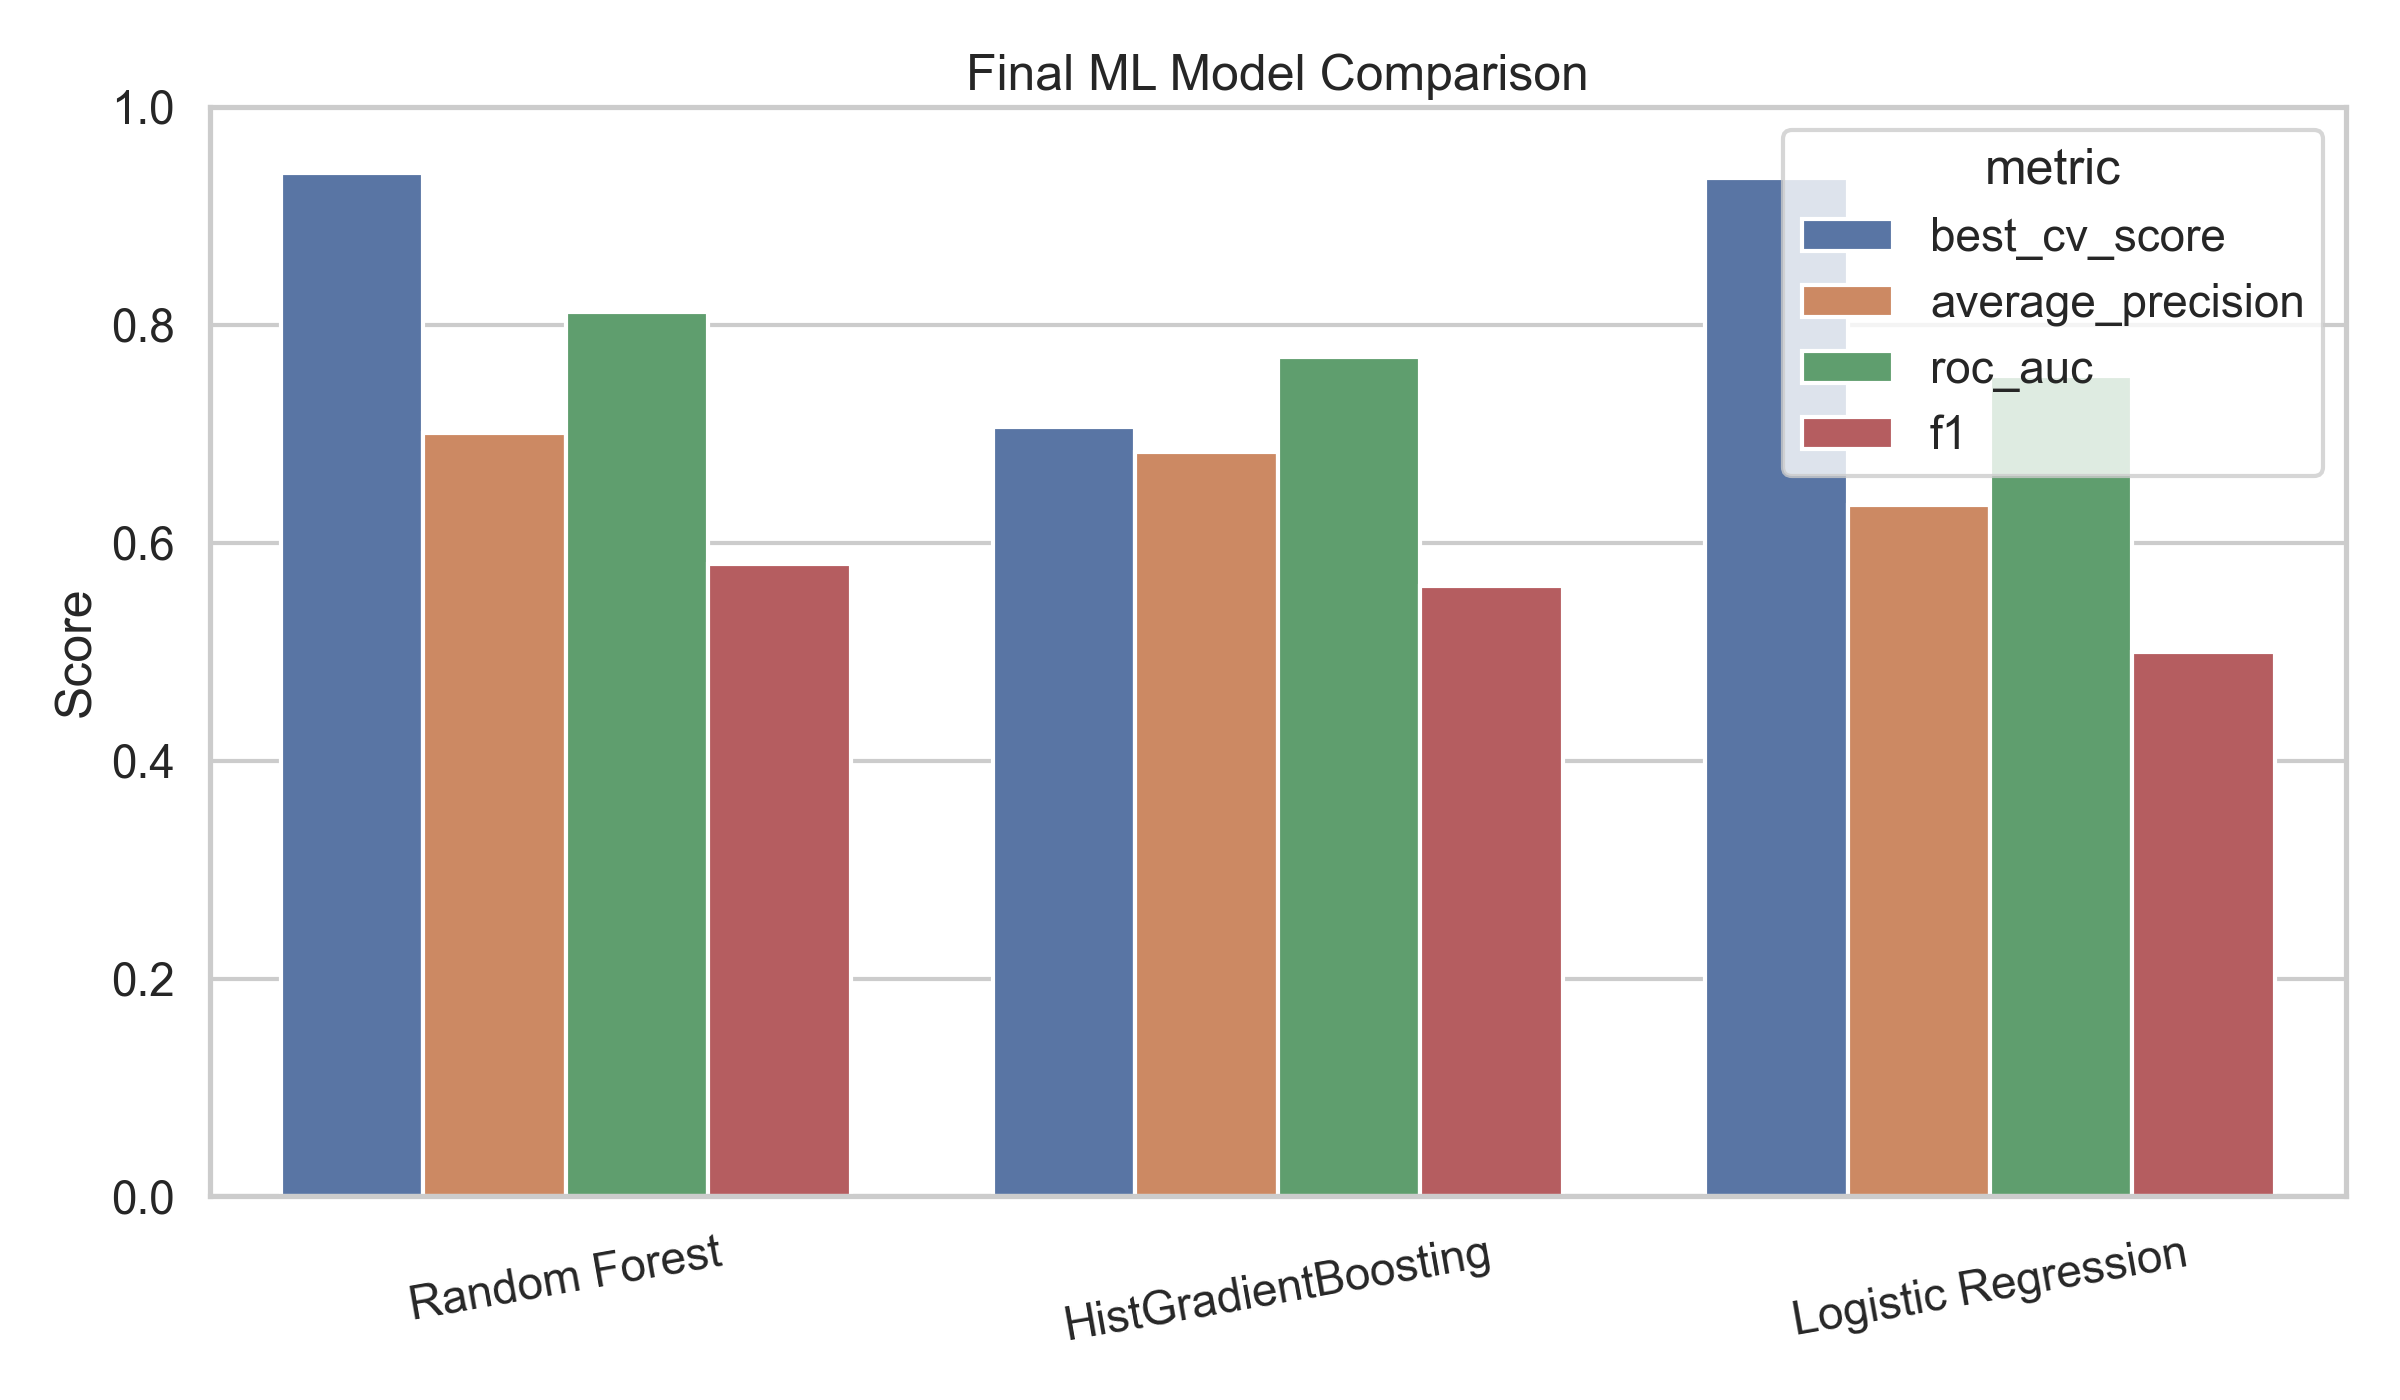

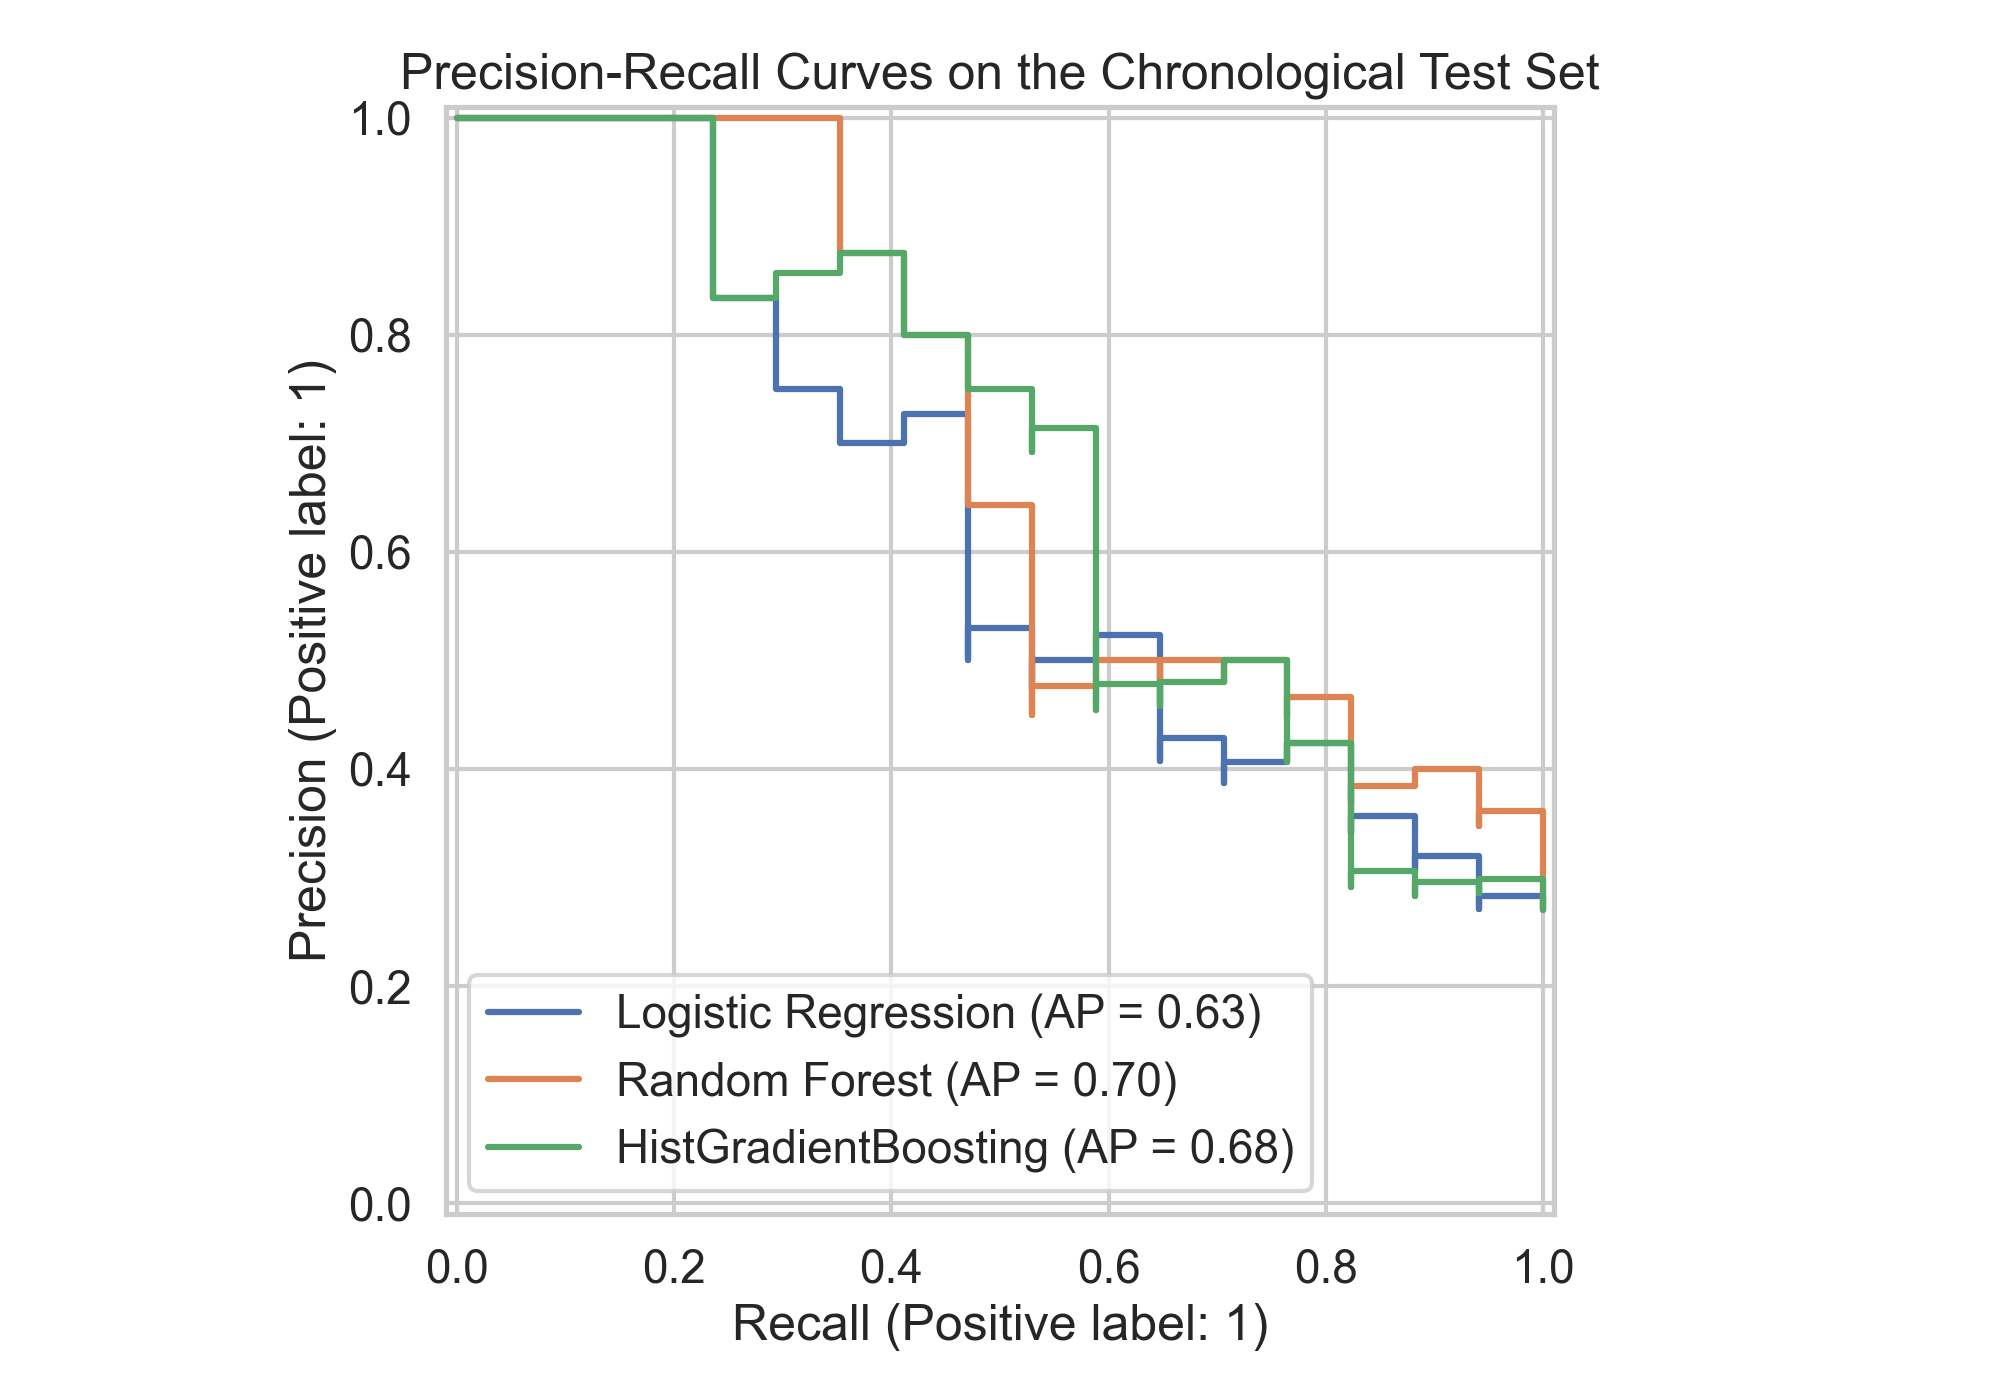

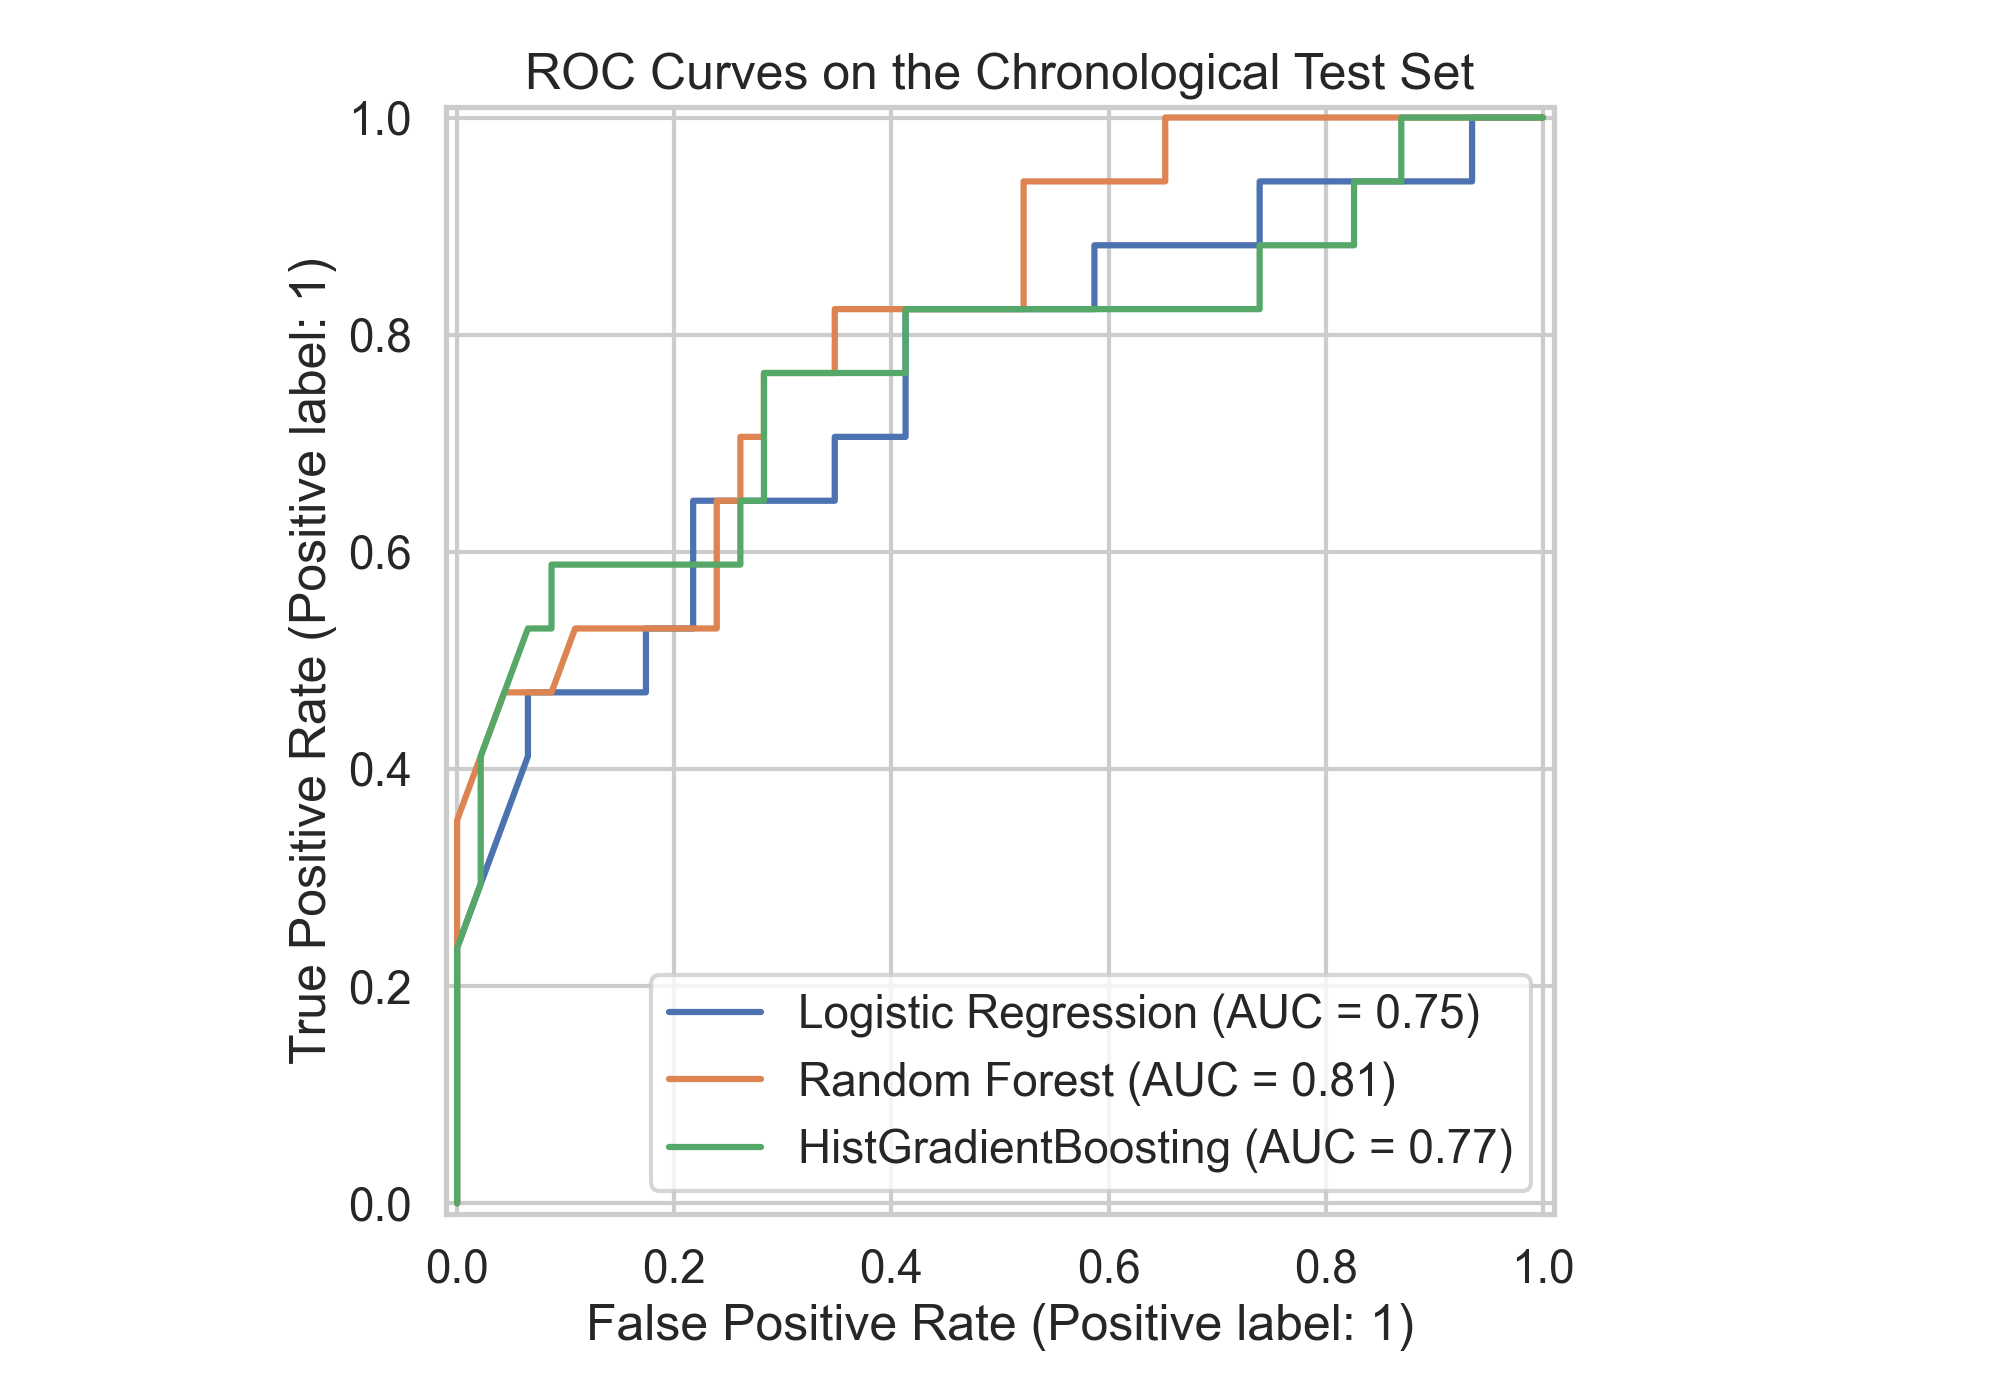

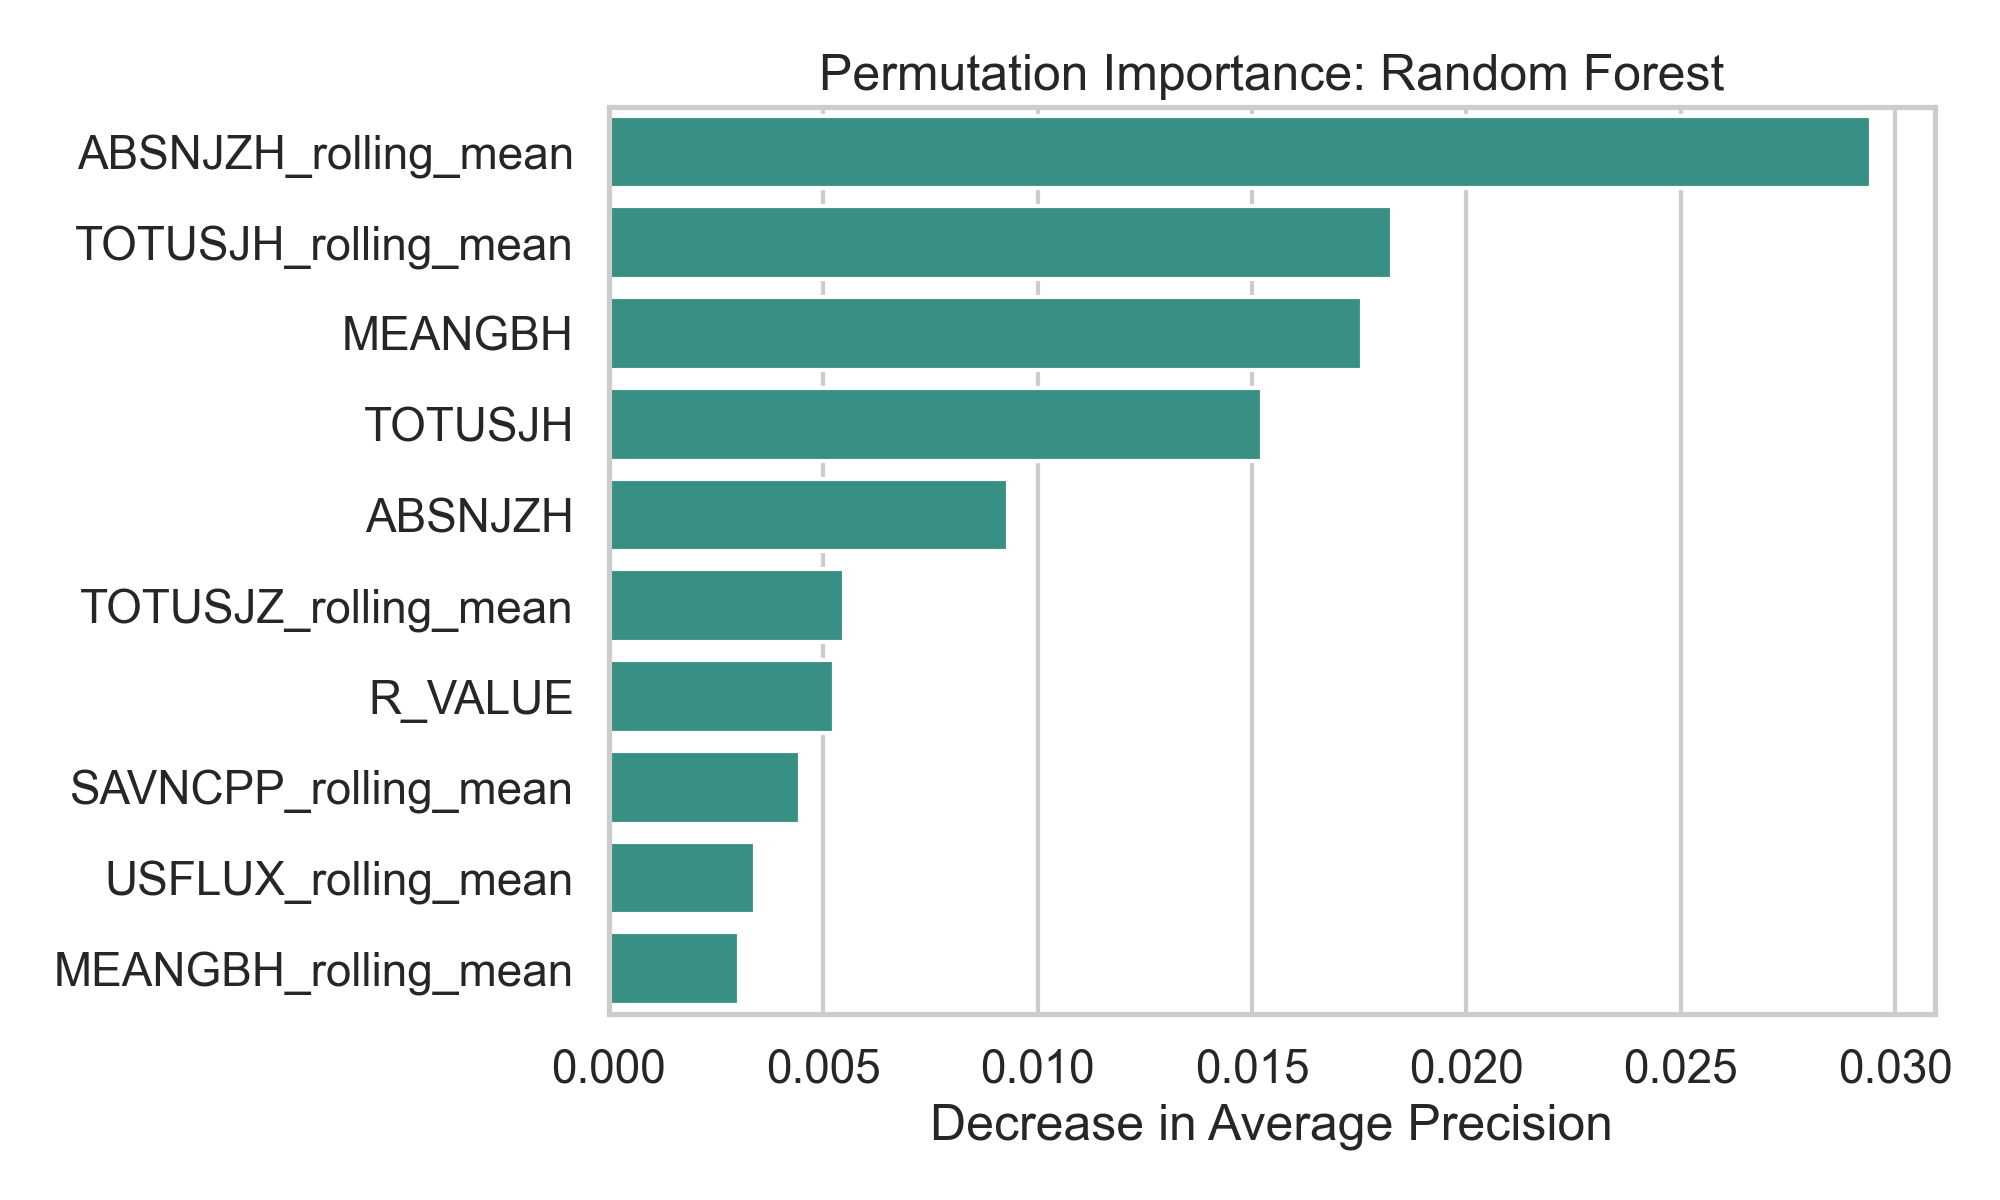

In [7]:
from IPython.display import Image, display

display(Image(filename=str(comparison_path)))
display(Image(filename=str(pr_path)))
display(Image(filename=str(roc_path)))
display(Image(filename=str(importance_path)))


## Final Interpretation

This final stage answers the main project question: can the active-region magnetic features and their short-term evolution provide useful predictive signal for a flare within the next 24 hours? The results here should be interpreted as a first research-style ML benchmark rather than an operational forecasting system.
